### Hybrid Model for Residential Water Consumption Category

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D, LSTM, Dense, Dropout, Multiply,
    Flatten, Lambda, RepeatVector, Permute
)
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.losses import Huber
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Define directory and load the data
dir_name = #replace with file path
df = pd.read_csv(f"{dir_name}/#Replace with file name")
df.head()

Mounted at /content/drive


,Year,Month,Residential Monthly Average,Commercial Monthly Average,Government Monthly Average,RAINFALL,TMAX,TMIN,TMEAN,WIND_SPEED,WIND_DIRECTION,RH
0,2010,1,4940168.0,702499.0,156935.0,5.080645,30.564516,23.909677,27.258065,2.354839,213.225806,84.258065
1,2010,2,3996492.0,601294.0,137278.0,0.571429,32.521429,23.550000,28.053571,2.607143,176.071429,78.071429
2,2010,3,4423759.0,654733.0,145150.0,1.706452,33.493548,24.390323,28.954839,2.741935,159.354839,78.096774
3,2010,4,4605206.0,672214.0,141869.0,4.133333,32.516667,24.800000,28.680000,2.100000,245.666667,82.166667
4,2010,5,4475865.0,642270.0,137791.0,1.848387,32.822581,25.522581,29.193548,1.903226,164.516129,83.064516


In [ ]:
# Normalize the features `RH` and `TMEAN` and the target `Residential Monthly Average`
scaler_features = StandardScaler()  # Using StandardScaler instead of MinMaxScaler for better robustness
scaler_target = MinMaxScaler()

# Scale input features
df[['RH', 'TMEAN']] = scaler_features.fit_transform(df[['RH', 'TMEAN']])

# Scale the target variable
df['Residential Monthly Average'] = scaler_target.fit_transform(df[['Residential Monthly Average']])

# Create additional lag features for RH and TMEAN
time_steps = 12
X, y = [], []

for i in range(len(df) - time_steps):
    # Lagged features
    X.append(df[['RH', 'TMEAN']].values[i:i+time_steps])
    y.append(df['Residential Monthly Average'].values[i+time_steps])  # Target variable

X = np.array(X)
y = np.array(y)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Model Architecture
def attention_block(inputs):
    attention_weights = Dense(1, activation="tanh")(inputs)
    attention_weights = Flatten()(attention_weights)
    attention_weights = Dense(inputs.shape[1], activation="softmax")(attention_weights)
    attention_weights = RepeatVector(inputs.shape[2])(attention_weights)
    attention_weights = Permute([2, 1])(attention_weights)
    weighted_inputs = Multiply()([inputs, attention_weights])
    return weighted_inputs

In [ ]:
input_layer = Input(shape=(time_steps, 2))  # Two features: RH and TMEAN

# Convolutional layers
conv1 = Conv1D(filters=32, kernel_size=3, activation='relu', padding='same')(input_layer)
conv2 = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(conv1)
maxpool = MaxPooling1D(pool_size=2)(conv2)

# LSTM layers
lstm1 = LSTM(units=32, return_sequences=True, dropout=0.3, recurrent_dropout=0.3)(maxpool)
lstm2 = LSTM(units=32, return_sequences=True, dropout=0.3, recurrent_dropout=0.3)(lstm1)

# Attention mechanism
attention_output = attention_block(lstm2)
attention_output = Lambda(lambda x: tf.reduce_sum(x, axis=1))(attention_output)

# Fully connected layers
dense1 = Dense(units=128, activation='relu')(attention_output)
dropout1 = Dropout(0.3)(dense1)
dense2 = Dense(units=64, activation='relu')(dropout1)
dropout2 = Dropout(0.3)(dense2)
output = Dense(units=1, activation='linear')(dropout2)

model = Model(inputs=input_layer, outputs=output)

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.01), loss=Huber(delta=1.0), metrics=['mae'])

# Early stopping to avoid overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [ ]:
# Train the model
history = model.fit(X_train, y_train, validation_data=(X_test, y_test),
                    epochs=100, batch_size=8, verbose=1, callbacks=[early_stopping])


Epoch 1/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 73ms/step - loss: 0.0534 - mae: 0.2648 - val_loss: 0.0129 - val_mae: 0.1341
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0183 - mae: 0.1573 - val_loss: 0.0225 - val_mae: 0.1714
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0196 - mae: 0.1532 - val_loss: 0.0085 - val_mae: 0.1111
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0209 - mae: 0.1668 - val_loss: 0.0109 - val_mae: 0.1310
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0214 - mae: 0.1685 - val_loss: 0.0076 - val_mae: 0.1013
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0058 - mae: 0.0850 - val_loss: 0.0168 - val_mae: 0.1665
Epoch 7/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0121 - mae: 0.1235 - val_loss: 0.0126 - val_mae: 0.1350
Epoch 8/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0100 - mae: 0.1103 - val_loss: 0.0075 - val_mae: 0.1016
Epoch 9/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - l

In [ ]:
# Predictions
y_pred = model.predict(X_test)

# Rescale predictions and true values
y_pred_rescaled = scaler_target.inverse_transform(y_pred)
y_test_rescaled = scaler_target.inverse_transform(y_test.reshape(-1, 1))

# Evaluate
mae = mean_absolute_error(y_test_rescaled, y_pred_rescaled)
rmse = np.sqrt(mean_squared_error(y_test_rescaled, y_pred_rescaled))
mape = np.mean(np.abs((y_test_rescaled - y_pred_rescaled) / y_test_rescaled)) * 100

print(f"Mean Absolute Error (MAE): {mae}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"Mean Absolute Percentage Error (MAPE): {mape}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 668ms/step
Mean Absolute Error (MAE): 139323.6896551724
Root Mean Squared Error (RMSE): 175367.9724362855
Mean Absolute Percentage Error (MAPE): 3.0066541775758817%


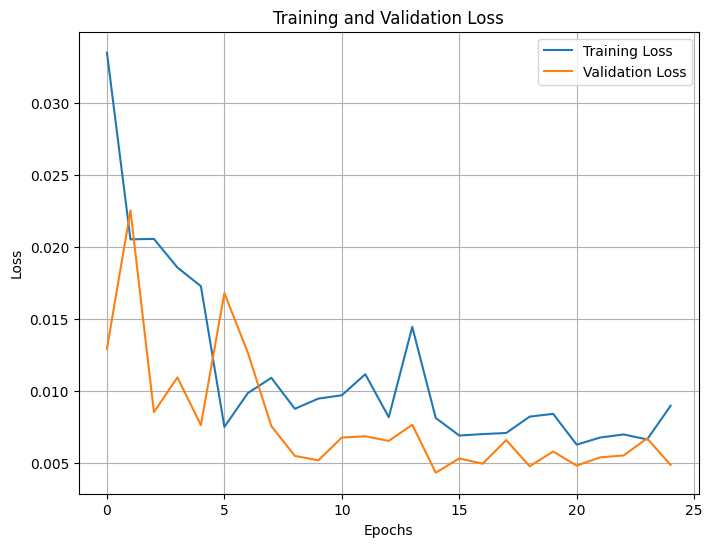

In [ ]:
# Plotting training and validation loss
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.grid(True)
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# Step 1: Scientific estimate for prediction range
dataset_end_year = int(df.iloc[-1]['Year'])  # Last year in the dataset
dataset_end_month = int(df.iloc[-1]['Month'])  # Last month in the dataset
last_date = datetime(dataset_end_year, dataset_end_month, 1)
forecast_horizon = 12  # Example: We predict up to 12 months into the future

future_dates = [last_date + timedelta(days=30*i) for i in range(1, forecast_horizon + 1)]

# Step 2: Predictions on the test set
y_pred = model.predict(X_test)
y_pred_rescaled = scaler_target.inverse_transform(y_pred)
y_test_rescaled = scaler_target.inverse_transform(y_test.reshape(-1, 1))

# Combine predictions and actual values with dates for the test set
test_dates = df.iloc[-len(y_test):][['Year', 'Month']]
test_dates = test_dates.apply(lambda row: datetime(int(row['Year']), int(row['Month']), 1), axis=1)
test_results = pd.DataFrame({
    'Date': test_dates,
    'Actual': y_test_rescaled.flatten(),
    'Predicted': y_pred_rescaled.flatten()
})

# Step 3: Generate future predictions
last_sequence = X[-1:]  # Take the last available sequence for prediction
future_predictions = []

for i in range(forecast_horizon):
    # Predict the next value
    next_prediction = model.predict(last_sequence)
    future_predictions.append(next_prediction[0][0])

    # Update the sequence with the predicted value
    next_rh = last_sequence[0, 1:, 0]  # Shift RH values
    next_tmean = last_sequence[0, 1:, 1]  # Shift TMEAN values

    predicted_rh = df['RH'].iloc[-1]  # Assuming RH remains constant for simplicity
    predicted_tmean = df['TMEAN'].iloc[-1]  # Assuming TMEAN remains constant for simplicity

    next_rh = np.append(next_rh, predicted_rh)
    next_tmean = np.append(next_tmean, predicted_tmean)

    # Update sequence
    last_sequence = np.array([np.column_stack((next_rh, next_tmean))])

# Rescale future predictions back to original scale
future_predictions_rescaled = scaler_target.inverse_transform(np.array(future_predictions).reshape(-1, 1))

# Create a DataFrame for future predictions
future_results = pd.DataFrame({
    'Date': future_dates,
    'Predicted': future_predictions_rescaled.flatten()
})

# Step 4: Export the results to CSV
test_results.to_csv('/content/test_predictions.csv', index=False)
future_results.to_csv('/content/future_predictions.csv', index=False)

# Display completion message
print("Export completed:")
print("- Test predictions saved as 'test_predictions.csv'")
print("- Future predictions saved as 'future_predictions.csv'")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 637ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Export completed:
- Test predictions saved as 'test_predictions.csv'
- Future predictions saved as 'future_predictions.csv'
